# Reproducing Bayesian DRO experiment

We ran the script given to use by the authors. The goal is to reproduce Figure 1.b. when the data-generating process (DGP) is a truncated normal and when $N=20$. We made the following changes to the script:

- For each replication, we run function `main_Bayesian_DRO` in parallel using the [joblib Parallel](https://joblib.readthedocs.io/en/latest/generated/joblib.Parallel.html) class. We did this to speed up the computation.
- We did not run `main_DRO`, `main_empirical`, `main_Bayesian_DRO_epsilon1`, `main_Bayesian_DRO_epsilon2`, `main_Bayesian_DRO_epsilon3`, and `main_empirical_DRO_Wasserstein`.
- To match Section 4.1, we set `b = 8`, `my_mean = 10`, and `my_std = 10`.
- For each replication, we save a CSV file containing the solution and cost for each epsilon via a pandas dataframe. Each replication file is called `result_k.csv`, where `k` is the replication number.

You can see the exact differences between the original file and our adapted file by running the `diff` command:

```bash
diff Bayesian_DRO_continuous.py reproduce_bdro_continuous.py
```

***

## Analysing results

In the following notebook, we concatenate all the CSV files together, then group by $\epsilon$.
In each replication $j = 1,\ldots,K$, we are given $N+1$ data points $\xi_1^{(j)}, \ldots, \xi_N^{(j)}, \xi_{N+1}^{(j)}$ where the first $N$ points are the training samples and the last point $\xi_{N+1}^{(j)}$ is the test sample.
For each $\epsilon$, we calculate the out-of-sample mean and variance of the objective function.
More specifically, for given $\epsilon$, the out-of-sample mean $\mu_{N+1}(\epsilon)$ and variance $v_{N+1}(\epsilon)$ is:
$$
    \mu_{N+1}(\epsilon) := \mathbb{E}_{\xi \sim \mathbb{P}^\star}~{[G(x(\epsilon), \xi)]} = \frac{1}{K}~\sum_{j=1}^{K}~{G(x^{(j)}(\epsilon), \xi_{N+1}^{(j)})} \\
    v_{N+1}(\epsilon) := \mathbb{V}_{\xi \sim \mathbb{P}^\star}~{[G(x(\epsilon), \xi)]} = \frac{1}{K-1}~\sum_{j=1}^{K}~{(G(x^{(j)}(\epsilon), \xi_{N+1}^{(j)}) - \mu_{N+1}(\epsilon))^2}
$$
where $\mathbb{P}^\star$ is the true data-generating process (DGP), $K$ is the number of replications, and $x^{(j)}(\epsilon)$ is the solution on replication $j = 1,\ldots,K$.

Out of curiosity, we also calculate the mean and variance solution variable $x$. 



In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bayesian_dro.Bayesian_DRO_continuous import cost, data_generation, EPSILON_SET

In [3]:
experiment_dir = Path("/dcs/large/u1508153/misdro/reproduce")
assert experiment_dir.exists()
replication = 200
results_df = pd.concat([pd.read_csv(experiment_dir / f"result_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon"])
results_df

bayesian_dro_sol  bayesian_dro_cost
replication epsilon                                     
0           0.001               18.70          34.927163
            0.002               18.93          35.617163
            0.005               19.35          36.877163
            0.010               19.90          38.527163
            0.020               20.62          40.687163
...                               ...                ...
199         1.000               28.49          61.282653
            1.500               29.10          63.112653
            2.000               29.20          63.412653
            2.500               39.73          95.002653
            3.000               41.86         101.392653

[3600 rows x 2 columns]

In [11]:
gb = results_df.groupby(by="epsilon")
mean_df = gb.mean()
var_df = gb.var()
var_df["bayesian_dro_cost"]

epsilon
0.001    493.588167
0.002    479.135127
0.005    452.814460
0.010    426.506254
0.020    399.517162
0.050    383.211307
0.100    405.395068
0.150    429.329619
0.200    458.242817
0.250    494.481749
0.300    520.656558
0.400    567.055656
0.500    595.128950
1.000    806.298651
1.500    877.938772
2.000    907.000405
2.500    654.940913
3.000    612.738532
Name: bayesian_dro_cost, dtype: float64

## Double check variance

For sanity sake, we double check the variance in `var_df` is being correctly calculated by pandas for a given epsilon:

In [10]:
epsilon = 2.0
cost_values = results_df.loc[results_df.index.get_level_values("epsilon") == epsilon]["bayesian_dro_cost"]
mu = np.mean(cost_values)
var = 1.0/(len(cost_values) -1) * np.sum((cost_values - mu)**2)
np.isclose(var_df.at[epsilon, "bayesian_dro_cost"], var)

True

## Plot like in Figure 2.b.

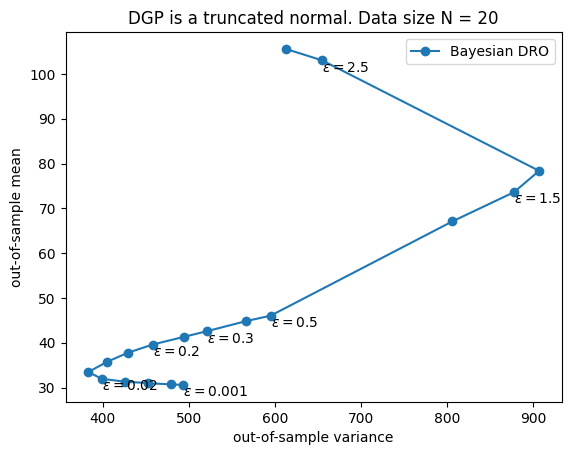

In [8]:
plt.plot(var_df["bayesian_dro_cost"], mean_df["bayesian_dro_cost"], marker='o', label="Bayesian DRO")
# plt.plot(var_df["wasserstein_dro_cost"], mean_df["wasserstein_dro_cost"], marker='*', label="Wasserstein DRO (p=2)")

plt.title(f"DGP is a truncated normal. Data size N = 20")
plt.legend()
plt.xlabel("out-of-sample variance")
plt.ylabel("out-of-sample mean")

for i, epsilon in enumerate(mean_df.index.values):
    if i % 2 == 0 and epsilon > 0.1:
        # plt.text(var_df["wasserstein_dro_cost"].iloc[i], mean_df["wasserstein_dro_cost"].iloc[i], label, ha='right', va='bottom')
        plt.text(var_df["bayesian_dro_cost"].iloc[i], mean_df["bayesian_dro_cost"].iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')
    
    elif i % 4 == 0 and epsilon <= 0.02:
        plt.text(var_df["bayesian_dro_cost"].iloc[i], mean_df["bayesian_dro_cost"].iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')
